In [25]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

<Axes: xlabel='temperatures', ylabel='vendes'>

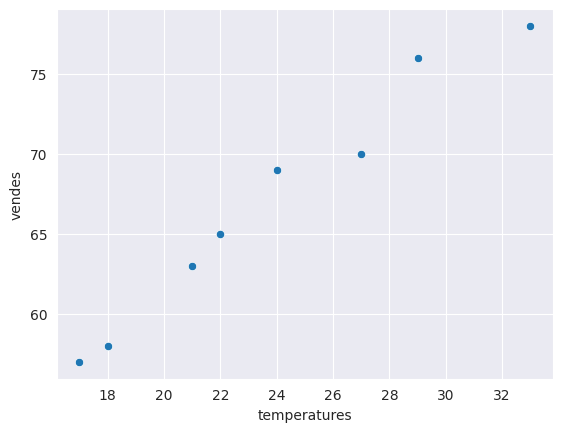

In [26]:
data = {'temperatures':[18,21,24,27,29,33,17,22],
        'vendes':[58,63,69,70,76,78,57,65]}

gelats = pd.DataFrame(data)
sns.set_style("darkgrid")
sns.scatterplot(data=gelats, x="temperatures", y="vendes")


<Axes: xlabel='temperatures', ylabel='vendes'>

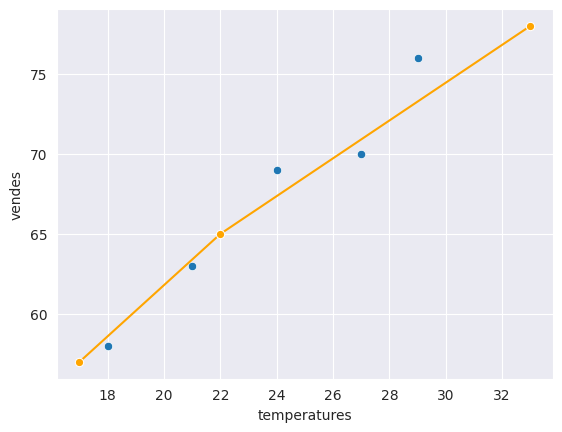

In [27]:
data = {'temperatures':[18,21,24,27,29,33,17,22],
        'vendes':[58,63,69,70,76,78,57,65],
        'p':['R','R','R','R','R','P','P','P']
       }

gelats = pd.DataFrame(data)
sns.set_style("darkgrid")
ax=sns.scatterplot(data=gelats[gelats.p=="R"], x="temperatures", y="vendes")
sns.lineplot(data=gelats[gelats.p=="P"],ax=ax.axes, x="temperatures", y="vendes", color="orange", marker='o', dashes=False)

In [28]:
from sklearn.linear_model import LinearRegression

from sklearn.model_selection import train_test_split


x= gelats.temperatures
y= gelats.vendes
x_train = gelats.iloc[0:5]['temperatures'].values.reshape(-1,1)
x_test = gelats.iloc[5:]['temperatures'].values.reshape(-1,1)
y_train = gelats.iloc[0:5]['vendes'].values.reshape(-1,1)
y_test = gelats.iloc[5:]['vendes'].values.reshape(-1,1)

x= gelats[['temperatures']]
y= gelats[['vendes']]

# Dividim en train (80%) i test (20%)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 0)



In [29]:
print ("------\nTRAIN\n------")
print(x_train)
print(y_train)
print ("------\nTEST\n------")
print(x_test)
print(y_test)

------
TRAIN
------
   temperatures
1            21
7            22
3            27
0            18
5            33
4            29
   vendes
1      63
7      65
3      70
0      58
5      78
4      76
------
TEST
------
   temperatures
6            17
2            24
   vendes
6      57
2      69


In [30]:
# Calculem la regressió
regression = LinearRegression()
#x_train
regression.fit(x_train, y_train)

LinearRegression()

In [31]:
y_pred = regression.predict(x_test)
print(y_pred)
print ('---')
print(y_test)

[[57.44725738]
 [66.97257384]]
---
   vendes
6      57
2      69


In [32]:
from sklearn.metrics import mean_squared_error,root_mean_squared_error, r2_score

# Mostrem els coeficent obtingut:
print('Coeficient \u03B21: %.5f' % regression.coef_.item())

# Valor del temre independent (X=0)
print('Terme independent \u03B20: %.5f' % regression.intercept_.item())

# Coeficient de R2
#print("Coeficient de determinació R^2:", regression.score(x, y))

# Error Quadràtic Mig (MSE)
print("MSE: %.4f" % mean_squared_error(y_test, y_pred))

# Arrel de l'Error Quadràtic Mig (RMSE)
print("RMSE: %.4f" % root_mean_squared_error(y_test, y_pred))

# R-quadrat
print('R-quadrat: %.5f' % r2_score(y_test, y_pred))


Coeficient β1: 1.36076
Terme independent β0: 34.31435
MSE: 2.1552
RMSE: 1.4681
R-quadrat: 0.94013


[Text(0.5, 0, 'y_test'), Text(0, 0.5, 'y_pred')]

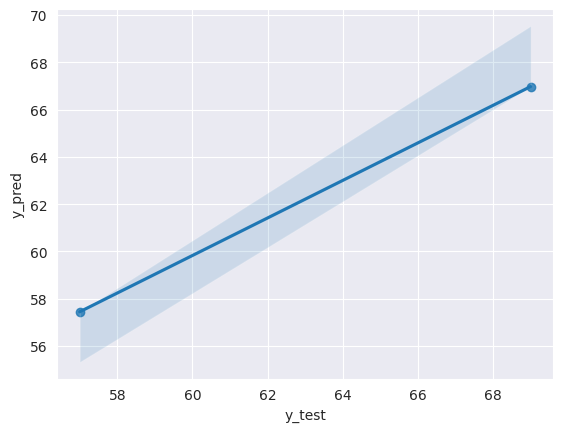

In [33]:
# Mostre ScatterPlot de y_pred i y_test
sns.set_style("darkgrid")
#sns.scatterplot(x=y_test, y=y_pred)
ax = sns.regplot(x=y_test, y=y_pred)
ax.set(xlabel='y_test', ylabel='y_pred')
